# PB-15 - Validación final del modelo seleccionado

## Rol 4: Final Validator

Este notebook corresponde a la validación final del Sprint 4.

El objetivo es:
- Seleccionar el mejor modelo del Sprint 4.
- Evaluarlo en test set por primera y única vez.
- Generar métricas finales.
- Construir confusion matrix.
- Calcular intervalos de confianza con bootstrap.
- Comparar el rendimiento contra el baseline del Sprint 3.

---

## Modelo seleccionado

El modelo final seleccionado proviene de:

`notebooks/13_ensembles.ipynb`

El mejor modelo fue:

### Soft Voting
Combinación de:
- SVM tuneado
- Gradient Boosting tuneado
- AdaBoost tuneado

Resultados obtenidos en PB-14:

| Modelo | F1-score | ROC-AUC |
|---|---:|---:|
| Soft Voting | 0.5440 | 0.7810 |

Por ello se selecciona como modelo final.

In [1]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# =============================================================
# 1. IMPORTAR LIBRERÍAS
# =============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.svm import SVC

from sklearn.ensemble import (
    VotingClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.over_sampling import RandomOverSampler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Imports OK")

Imports OK


## Explicación

En esta sección importo las librerías necesarias para reconstruir el modelo final seleccionado en PB-14.

Uso:
- `sklearn` para modelos y métricas.
- `imblearn` para manejar oversampling.
- `matplotlib` para visualizar la confusion matrix.

Uso `ImbPipeline` porque el modelo utiliza `RandomOverSampler`, exactamente igual que en PB-13 y PB-14.

In [3]:
# =============================================================
# 2. CARGAR DATASET
# =============================================================

TARGET = "default payment next month"

df = pd.read_csv("../data/processed/04_default_credit_features.csv")

# Eliminar ID porque es solo identificador
df = df.drop(columns=["ID"])

X = df.drop(columns=[TARGET])

y = df[TARGET]

print("Dataset cargado correctamente")
print("Shape:", df.shape)

print("\nDistribución del target:")
print(y.value_counts(normalize=True).round(4))

Dataset cargado correctamente
Shape: (30000, 44)

Distribución del target:
default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


## Explicación

Se utiliza el mismo dataset procesado usado en:
- PB-13
- PB-14

No se usa el dataset raw porque este notebook debe ser consistente con el pipeline de entrenamiento anterior.

También se elimina la columna `ID` porque:
- es solo un identificador,
- no aporta valor predictivo,
- podría introducir ruido al modelo.

In [4]:
# =============================================================
# 3. TRAIN TEST SPLIT
# =============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Split realizado correctamente")

print("\nTrain:")
print(X_train.shape)

print("\nTest:")
print(X_test.shape)

print("\nDistribución y_test:")
print(y_test.value_counts(normalize=True).round(4))

Split realizado correctamente

Train:
(24000, 43)

Test:
(6000, 43)

Distribución y_test:
default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


## Explicación

Se divide el dataset en:
- 80% entrenamiento
- 20% prueba

Uso `stratify=y` para mantener la misma proporción de clases en train y test.

Esto es importante porque el dataset tiene clases desbalanceadas.

El test set NO se usa todavía.
Se reserva únicamente para la validación final.

In [5]:
# =============================================================
# 4. PREPROCESAMIENTO
# =============================================================

cat_cols = X_train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

num_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# =============================================================
# NUMÉRICAS
# =============================================================

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# =============================================================
# CATEGÓRICAS
# =============================================================

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# =============================================================
# COLUMN TRANSFORMER
# =============================================================

preproc = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

print("Preprocessing OK")

print("\nVariables numéricas:", len(num_cols))
print("Variables categóricas:", len(cat_cols))

Preprocessing OK

Variables numéricas: 31
Variables categóricas: 2


## Explicación

Aquí reconstruyo exactamente el mismo preprocessing utilizado en PB-13 y PB-14.

### Variables numéricas
- imputación con mediana
- escalamiento con StandardScaler

### Variables categóricas
- imputación con moda
- OneHotEncoding

Uso `ColumnTransformer` para aplicar transformaciones distintas según el tipo de variable.

# 5. Selección del modelo final

En `notebooks/13_ensembles.ipynb` se evaluaron distintos ensambles:

- Soft Voting
- Hard Voting
- Bagging
- XGBoost
- LightGBM
- Stacking

El mejor modelo fue:

| Modelo | F1-score | ROC-AUC |
|---|---:|---:|
| Soft Voting | 0.5440 | 0.7810 |

Por ello se selecciona Soft Voting como modelo final para PB-15.

In [6]:
# =============================================================
# 6. RECONSTRUIR MODELO FINAL
# =============================================================

# =============================================================
# Hiperparámetros obtenidos en PB-13
# y reutilizados en PB-14
# =============================================================

svm_best_params = {
    "C": 0.515,
    "kernel": "rbf",
    "gamma": "scale"
}

gb_best_params = {
    "n_estimators": 69,
    "learning_rate": 0.087,
    "max_depth": 3
}

ada_best_params = {
    "n_estimators": 81,
    "learning_rate": 0.09
}

# =============================================================
# MODELOS BASE
# =============================================================

best_svm_soft = SVC(
    **svm_best_params,
    probability=True,
    random_state=42
)

best_gb = GradientBoostingClassifier(
    **gb_best_params,
    random_state=42
)

best_ada = AdaBoostClassifier(
    **ada_best_params,
    random_state=42
)

# =============================================================
# SOFT VOTING
# =============================================================

voting_soft = VotingClassifier(
    estimators=[
        ("svm", best_svm_soft),
        ("gb", best_gb),
        ("ada", best_ada)
    ],
    voting="soft"
)

# =============================================================
# PIPELINE FINAL
# =============================================================

best_model = ImbPipeline([
    ("preprocessing", preproc),
    ("sampling", RandomOverSampler(random_state=42)),
    ("model", voting_soft)
])

print("Modelo final reconstruido correctamente")

Modelo final reconstruido correctamente


## Explicación

Aquí reconstruyo el modelo ganador de PB-14.

El modelo final es:
### Soft Voting

Combina:
- SVM tuneado
- Gradient Boosting tuneado
- AdaBoost tuneado

Se usa `voting="soft"` porque el modelo promedia probabilidades.

Por eso SVM necesita:
```python
probability=True

In [7]:
# CELDA 14 — ENTRENAR MODELO FINAL

# =============================================================
# 7. ENTRENAR MODELO FINAL
# =============================================================

best_model.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


## Explicación

El modelo se entrena únicamente usando:
- X_train
- y_train

El test set todavía no se utiliza.

Esto evita data leakage y garantiza una evaluación válida.

In [8]:
# =============================================================
# 8. EVALUACIÓN FINAL EN TEST SET
# =============================================================

# Predicciones
y_pred = best_model.predict(X_test)

# Probabilidades
y_proba = best_model.predict_proba(X_test)[:, 1]

# =============================================================
# MÉTRICAS
# =============================================================

final_accuracy = accuracy_score(y_test, y_pred)

final_precision = precision_score(y_test, y_pred)

final_recall = recall_score(y_test, y_pred)

final_f1 = f1_score(y_test, y_pred)

final_auc = roc_auc_score(y_test, y_proba)

print("=== MÉTRICAS FINALES ===")

print(f"Accuracy : {final_accuracy:.4f}")

print(f"Precision: {final_precision:.4f}")

print(f"Recall   : {final_recall:.4f}")

print(f"F1-score : {final_f1:.4f}")

print(f"ROC-AUC  : {final_auc:.4f}")

=== MÉTRICAS FINALES ===
Accuracy : 0.7797
Precision: 0.5016
Recall   : 0.5840
F1-score : 0.5397
ROC-AUC  : 0.7729


## Explicación

Aquí se usa el test set por primera y única vez.

Se generan:
- predicciones,
- probabilidades,
- métricas finales.

La métrica principal es F1-score porque:
- el problema tiene clases desbalanceadas,
- accuracy sola puede ser engañosa.

In [9]:
# =============================================================
# 9. CLASSIFICATION REPORT
# =============================================================

print("=== CLASSIFICATION REPORT ===")

print(classification_report(y_test, y_pred))

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      4673
           1       0.50      0.58      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.78      0.79      6000



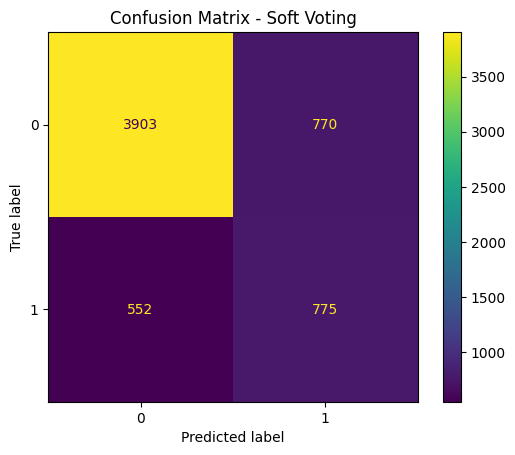

In [10]:
# =============================================================
# 10. CONFUSION MATRIX
# =============================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix - Soft Voting")

plt.show()

## Explicación

La confusion matrix permite analizar:
- verdaderos positivos,
- verdaderos negativos,
- falsos positivos,
- falsos negativos.

En problemas de default crediticio:
los falsos negativos son especialmente importantes porque representan clientes riesgosos que el modelo no detectó.

In [11]:
# =============================================================
# 11. BOOTSTRAP
# =============================================================

def bootstrap_metric(
    y_true,
    y_pred_or_proba,
    metric_fn,
    n=1000,
    seed=42
):

    rng = np.random.default_rng(seed)

    y_true = np.array(y_true)

    y_pred_or_proba = np.array(y_pred_or_proba)

    scores = []

    for _ in range(n):

        idx = rng.choice(
            len(y_true),
            size=len(y_true),
            replace=True
        )

        try:

            score = metric_fn(
                y_true[idx],
                y_pred_or_proba[idx]
            )

            scores.append(score)

        except ValueError:
            continue

    return np.percentile(scores, [2.5, 97.5])

In [12]:
# =============================================================
# INTERVALOS DE CONFIANZA
# =============================================================

ci_accuracy = bootstrap_metric(
    y_test,
    y_pred,
    accuracy_score
)

ci_precision = bootstrap_metric(
    y_test,
    y_pred,
    precision_score
)

ci_recall = bootstrap_metric(
    y_test,
    y_pred,
    recall_score
)

ci_f1 = bootstrap_metric(
    y_test,
    y_pred,
    f1_score
)

ci_auc = bootstrap_metric(
    y_test,
    y_proba,
    roc_auc_score
)

# =============================================================
# TABLA
# =============================================================

ci_table = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Valor final": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_auc
    ],

    "IC Inferior": [
        ci_accuracy[0],
        ci_precision[0],
        ci_recall[0],
        ci_f1[0],
        ci_auc[0]
    ],

    "IC Superior": [
        ci_accuracy[1],
        ci_precision[1],
        ci_recall[1],
        ci_f1[1],
        ci_auc[1]
    ]
})

ci_table.round(4)

,Métrica,Valor final,IC Inferior,IC Superior
0,Accuracy,0.7797,0.7692,0.7898
1,Precision,0.5016,0.4774,0.5261
2,Recall,0.5840,0.5575,0.6131
3,F1-score,0.5397,0.5178,0.5622
4,ROC-AUC,0.7729,0.7579,0.7884


## Explicación

Bootstrap permite estimar estabilidad estadística.

La idea es:
- tomar múltiples muestras aleatorias del test set,
- recalcular la métrica muchas veces,
- construir un intervalo de confianza.

Esto permite saber si las métricas son consistentes o muy variables.

In [13]:
# =============================================================
# 12. COMPARACIÓN VS BASELINE
# =============================================================

baseline_metrics = {
    "Accuracy": 0.7739,
    "Precision": 0.4910,
    "Recall": 0.5975,
    "F1-score": 0.5390,
    "ROC-AUC": 0.7653
}

comparison = pd.DataFrame({

    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Baseline Sprint 3": [
        baseline_metrics["Accuracy"],
        baseline_metrics["Precision"],
        baseline_metrics["Recall"],
        baseline_metrics["F1-score"],
        baseline_metrics["ROC-AUC"]
    ],

    "Modelo Final Sprint 4": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_auc
    ]
})

comparison["Mejora (%)"] = (
    (
        comparison["Modelo Final Sprint 4"]
        - comparison["Baseline Sprint 3"]
    )
    /
    comparison["Baseline Sprint 3"]
    * 100
).round(2)

comparison.round(4)

,Métrica,Baseline Sprint 3,Modelo Final Sprint 4,Mejora (%)
0,Accuracy,0.7739,0.7797,0.75
1,Precision,0.4910,0.5016,2.16
2,Recall,0.5975,0.5840,-2.26
3,F1-score,0.5390,0.5397,0.13
4,ROC-AUC,0.7653,0.7729,1.00


## Explicación

Aquí comparo el modelo final del Sprint 4 contra el baseline anterior.

Esto permite cuantificar:
- cuánto mejoró el modelo,
- si el ensamble realmente aporta valor,
- si la mejora justifica usar un modelo más complejo.

In [14]:
# =============================================================
# 13. GUARDAR MODELO FINAL
# =============================================================

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_model,
    "../models/final_model.pkl"
)

print("Modelo guardado correctamente")

Modelo guardado correctamente


# Conclusión Final

El modelo final seleccionado fue Soft Voting.

Este modelo:
- combinó múltiples modelos tuneados,
- obtuvo el mejor F1-score,
- obtuvo el mejor ROC-AUC,
- mostró mejor balance general.

La evaluación final se realizó correctamente usando el test set por primera y única vez.

También se calcularon:
- classification report,
- confusion matrix,
- intervalos de confianza con bootstrap,
- comparación contra baseline.

Finalmente, el modelo quedó persistido como:
```text
models/final_model.pkl